In [ ]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

In [ ]:
# Read CSV data
data = pd.read_csv("/content/train_u6lujuX_CVtuZ9i (1).csv")

In [ ]:
# Preview data
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Preview data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# Check missing values
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# Percent of missing "Gender"
print('Percent of missing "Gender" records is %.2f%%' % ((data['Gender'].isnull().sum() / data.shape[0]) * 100))
print("Number of people who take a loan grouped by gender:")
print(data['Gender'].value_counts())

Percent of missing "Gender" records is 2.12%
Number of people who take a loan grouped by gender:
Gender
Male      489
Female    112
Name: count, dtype: int64


/tmp/ipykernel_4476/4180233968.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=data, palette='Set2')


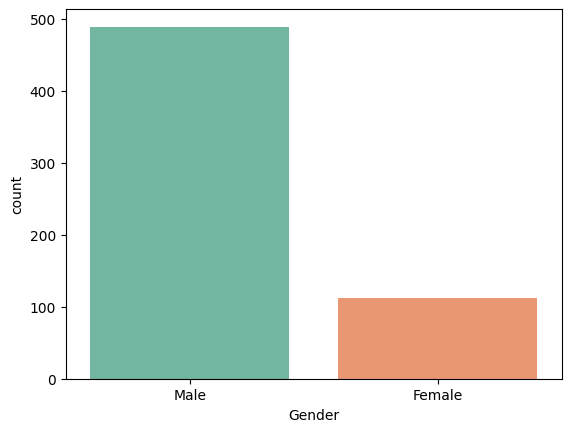

In [ ]:
sns.countplot(x='Gender', data=data, palette='Set2')
plt.show()

In [ ]:
# Percent of missing "Married"
print('Percent of missing "Married" records is %.2f%%' % ((data['Married'].isnull().sum() / data.shape[0]) * 100))
print("Number of people who take a loan grouped by marital status:")
print(data['Married'].value_counts())

Percent of missing "Married" records is 0.49%
Number of people who take a loan grouped by marital status:
Married
Yes    398
No     213
Name: count, dtype: int64


/tmp/ipykernel_4476/3740980718.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Married', data=data, palette='Set2')


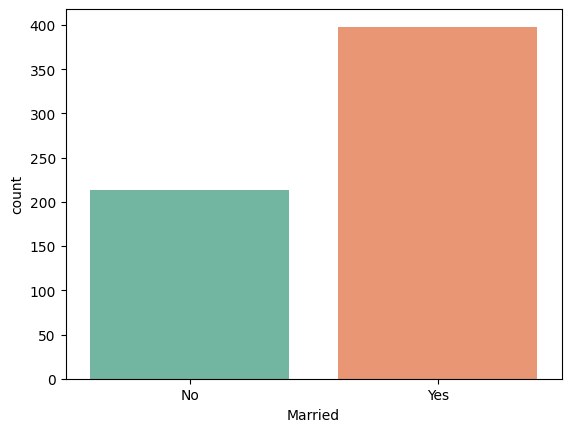

In [ ]:
sns.countplot(x='Married', data=data, palette='Set2')
plt.show()

In [ ]:
# Percent of missing "Dependents"
print('Percent of missing "Dependents" records is %.2f%%' % ((data['Dependents'].isnull().sum() / data.shape[0]) * 100))
print("Number of people who take a loan grouped by dependents:")
print(data['Dependents'].value_counts())

Percent of missing "Dependents" records is 2.44%
Number of people who take a loan grouped by dependents:
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


/tmp/ipykernel_4476/2189279554.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dependents', data=data, palette='Set2')


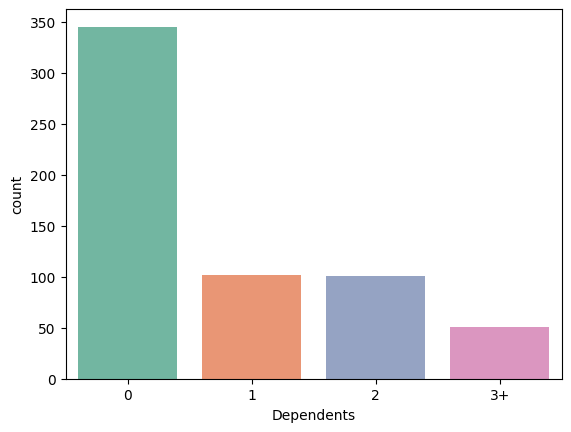

In [ ]:
sns.countplot(x='Dependents', data=data, palette='Set2')
plt.show()

In [ ]:
# Percent of missing "Self_Employed"
print('Percent of missing "Self_Employed" records is %.2f%%' % ((data['Self_Employed'].isnull().sum() / data.shape[0]) * 100))
print("Number of people who take a loan grouped by self employment:")
print(data['Self_Employed'].value_counts())

Percent of missing "Self_Employed" records is 5.21%
Number of people who take a loan grouped by self employment:
Self_Employed
No     500
Yes     82
Name: count, dtype: int64


/tmp/ipykernel_4476/1912287040.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Self_Employed', data=data, palette='Set2')


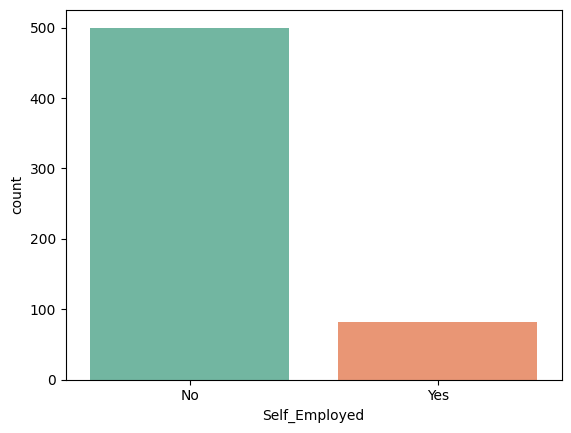

In [ ]:
sns.countplot(x='Self_Employed', data=data, palette='Set2')
plt.show()

In [ ]:
# Percent of missing "LoanAmount"
print('Percent of missing "LoanAmount" records is %.2f%%' % ((data['LoanAmount'].isnull().sum() / data.shape[0]) * 100))

Percent of missing "LoanAmount" records is 3.58%


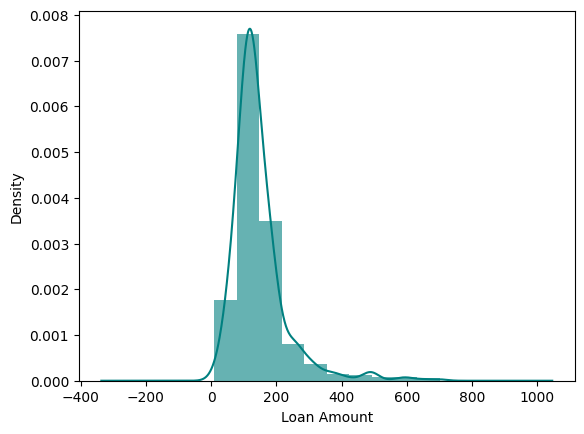

In [ ]:
ax = data["LoanAmount"].hist(density=True,stacked=True,color='teal',alpha=0.6)
data["LoanAmount"].plot(kind='density',color='teal')
ax.set(xlabel='Loan Amount')
plt.show()

In [ ]:
# Percent of missing "Loan_Amount_Term"
print('Percent of missing "Loan_Amount_Term" records is %.2f%%' % ((data['Loan_Amount_Term'].isnull().sum() / data.shape[0]) * 100))
print("Number of people who take a loan grouped by loan amount term:")
print(data['Loan_Amount_Term'].value_counts())

Percent of missing "Loan_Amount_Term" records is 2.28%
Number of people who take a loan grouped by loan amount term:
Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64


/tmp/ipykernel_4476/2510613479.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Amount_Term',data=data,palette='Set2')


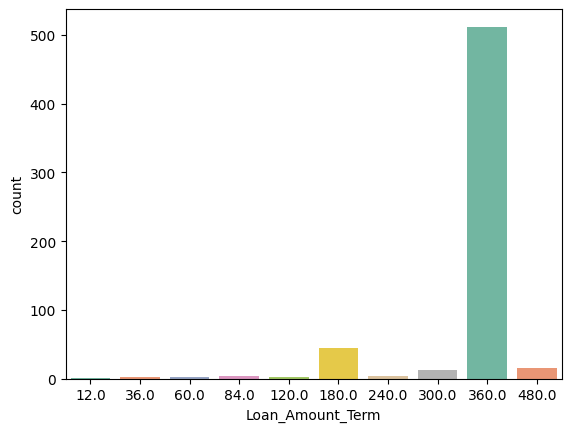

In [ ]:
sns.countplot(x='Loan_Amount_Term',data=data,palette='Set2')
plt.show()

In [ ]:
# Percent of missing "Credit_History"
print('Percent of missing "Credit_History" records is %.2f%%' % ((data['Credit_History'].isnull().sum() / data.shape[0]) * 100))
print("Number of people who take a loan grouped by credit history:")
print(data['Credit_History'].value_counts())

Percent of missing "Credit_History" records is 8.14%
Number of people who take a loan grouped by credit history:
Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


/tmp/ipykernel_4476/897178578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=data, palette='Set2')


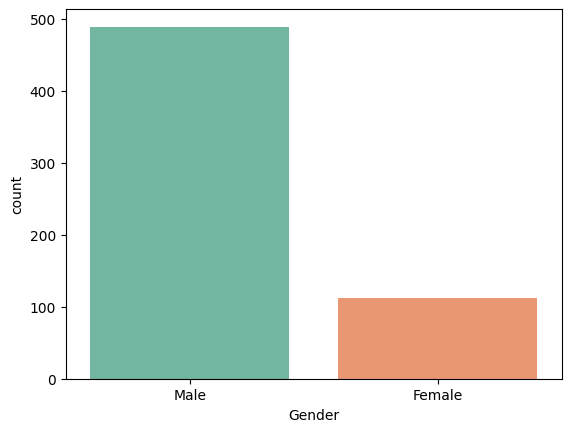

In [ ]:
# Create a count plot to visualize the number of applicants by gender
sns.countplot(x='Gender', data=data, palette='Set2')
# Display the plot
plt.show()

In [ ]:
# Create a copy of the original dataset so that the original data remains unchanged
train_data = data.copy()

# Fill missing Gender values with the most frequently occurring value
train_data['Gender'] = train_data['Gender'].fillna(train_data['Gender'].value_counts().idxmax())

# Check the number of missing values remaining in the Gender column
train_data['Gender'].isnull().sum()

# Fill missing Married values with the most frequently occurring value
train_data['Married'] = train_data['Married'].fillna(train_data['Married'].value_counts().idxmax())

# Check the number of missing values remaining in the Married column
train_data['Married'].isnull().sum()

# Fill missing Dependents values with the most frequently occurring value
train_data['Dependents'] = train_data['Dependents'].fillna(train_data['Dependents'].value_counts().idxmax())

# Check the number of missing values remaining in the Dependents column
train_data['Dependents'].isnull().sum()

# Fill missing Self_Employed values with the most frequently occurring value
train_data['Self_Employed'] = train_data['Self_Employed'].fillna(train_data['Self_Employed'].value_counts().idxmax())

# Check the number of missing values remaining in the Self_Employed column
train_data['Self_Employed'].isnull().sum()

# Fill missing LoanAmount values with the median loan amount
train_data['LoanAmount'] = train_data['LoanAmount'].fillna(train_data['LoanAmount'].median())

# Check the number of missing values remaining in the LoanAmount column
train_data['LoanAmount'].isnull().sum()

# Fill missing Loan_Amount_Term values with the most frequently occurring loan term
train_data['Loan_Amount_Term'] = train_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].value_counts().idxmax())

# Check the number of missing values remaining in the Loan_Amount_Term column
train_data['Loan_Amount_Term'].isnull().sum()

# Fill missing Credit_History values with the most frequently occurring value
train_data['Credit_History'] = train_data['Credit_History'].fillna(train_data['Credit_History'].value_counts().idxmax())

# Check the number of missing values remaining in the Credit_History column
train_data['Credit_History'].isnull().sum()

np.int64(0)

In [ ]:
# Check the number of missing (null) values in each column
train_data.isnull().sum()

# Display the train_data DataFrame
train_data


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Create mappings to convert categorical values into numerical values for
gender_stat = {"Female": 0, "Male": 1}
yes_no_stat = {"No": 0, "Yes": 1}
dependents_stat = {"0": 0, "1": 1, "2": 2, "3+": 3}
education_stat = {"Not Graduate": 0, "Graduate": 1}
property_stat = {"Semiurban": 0, "Urban": 1, "Rural": 2}

In [ ]:
train_data['Gender'] = (train_data['Gender'].replace(gender_stat).infer_objects(copy=False))
train_data[['Gender']].head()
train_data['Married'] = (train_data['Married'].replace(yes_no_stat).infer_objects(copy=False))
train_data[['Married']].head()
train_data['Dependents'] = (train_data['Dependents'].replace(dependents_stat).infer_objects(copy=False))
train_data[['Dependents']].head()
train_data['Education'] = (train_data['Education'].replace(education_stat).infer_objects(copy=False))
train_data[['Education']].head()
train_data['Self_Employed'] = (train_data['Self_Employed'].replace(yes_no_stat).infer_objects(copy=False))
train_data[['Self_Employed']].head()
train_data['Property_Area'] = (train_data['Property_Area'].replace(property_stat).infer_objects(copy=False))
train_data[['Property_Area']].head()

/tmp/ipykernel_4476/1634721228.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data['Gender'] = (train_data['Gender'].replace(gender_stat).infer_objects(copy=False))
/tmp/ipykernel_4476/1634721228.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data['Married'] = (train_data['Married'].replace(yes_no_stat).infer_objects(copy=False))
/tmp/ipykernel_4476/1634721228.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly ca

,Property_Area
0,1
1,2
2,1
3,1
4,1


In [ ]:
train_data.head()
train_data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(7), object(2)
memory usage: 62.5+ KB


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
#Separate feature and target
x = train_data.iloc[:, 1:12]
y = train_data.iloc[:, 12]
# Display Features
x.head()
# Display Target
y.head()

,Loan_Status
0,Y
1,N
2,Y
3,Y
4,Y


In [ ]:
# Define the classifiers, create positions for the graph, and initialize a list to store their scores
classifier = ('Gradient Boosting','Random Forest','Decision Tree','K-Nearest Neighbor','SVM')
y_pos = np.arange(len(classifier))
score = []

In [ ]:
# Train the Gradient Boosting classifier, evaluate its accuracy using 5-fold cross-validation,
# store the mean accuracy, and display the classification accuracy as a percentage
clf = GradientBoostingClassifier()
scores = cross_val_score(clf,x,y,cv=5)
score.append(scores.mean())
print('The accuracy of classification is %.2f%%'% (scores.mean() * 100))

The accuracy of classification is 77.69%


In [ ]:
# Train the Random Forest classifier, evaluate its accuracy using 5-fold cross-validation,
# store the mean accuracy, and display the classification accuracy as a percentage
clf = RandomForestClassifier(n_estimators=10,random_state=42)
scores = cross_val_score(clf,x,y,cv=5)
score.append(scores.mean())
print('The accuracy of classification is %.2f%%'% (scores.mean() * 100))

The accuracy of classification is 75.90%


In [ ]:
# Train the Decision Tree classifier, evaluate its accuracy using 5-fold cross-validation,
# store the mean accuracy, and display the classification accuracy as a percentage
clf = DecisionTreeClassifier(random_state=42)
scores = cross_val_score(clf,x,y,cv=5)
score.append(scores.mean())
print('The accuracy of classification is %.2f%%'% (scores.mean() * 100))

The accuracy of classification is 70.04%


In [ ]:
# Train the K-Nearest Neighbors classifier, evaluate its accuracy using 5-fold cross-validation,
# store the mean accuracy, and display the classification accuracy as a percentage
clf = KNeighborsClassifier()
scores = cross_val_score(clf,x,y,cv=5)
score.append(scores.mean())
print('The accuracy of classification is %.2f%%'% (scores.mean() * 100))

The accuracy of classification is 61.40%


In [ ]:
# Train the Linear SVM classifier, evaluate its accuracy using 5-fold cross-validation,
# store the mean accuracy, and display the classification accuracy as a percentage
clf = svm.LinearSVC(max_iter=5000,random_state=42)
scores = cross_val_score(clf,x,y,cv=5)
score.append(scores.mean())
print('The accuracy of classification is %.2f%%'% (scores.mean() * 100))

The accuracy of classification is 80.78%


In [ ]:
# Display the accuracy score of each classifier as a percentage
for name, result in zip(classifier, score):
    print(f'{name}: {result * 100:.2f}%')

Gradient Boosting: 77.69%
Random Forest: 75.90%
Decision Tree: 70.04%
K-Nearest Neighbor: 61.40%
SVM: 80.78%


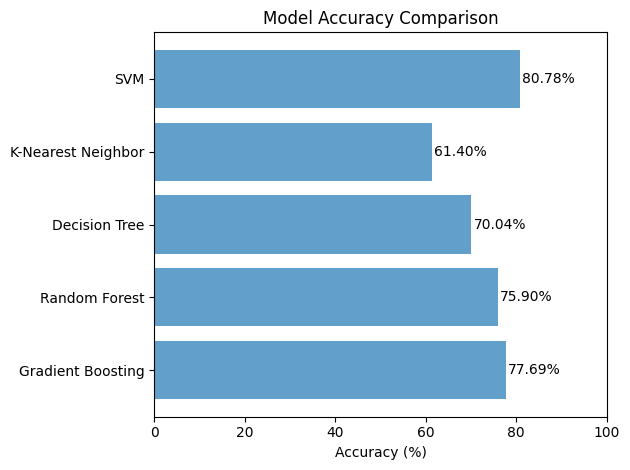

In [ ]:
# Compare the accuracy of all classifiers using a horizontal bar chart.
plt.barh(y_pos, np.array(score[:len(classifier)]) * 100, align='center', alpha=0.7)
plt.yticks(y_pos, classifier)
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')

for i, v in enumerate(np.array(score[:len(classifier)]) * 100):
    plt.text(v + 0.5, i, f'{v:.2f}%', va='center')

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
# Find the classifier with the highest accuracy and display its name and accuracy
# Ensure to only consider scores for existing classifiers by slicing the score list
relevant_scores = score[:len(classifier)]
best_index = np.argmax(relevant_scores)
best_classifier = classifier[best_index]
best_score = relevant_scores[best_index]
print(f'Best classifier: {best_classifier}')
print(f'Best accuracy: {best_score * 100:.2f}%')

Best classifier: SVM
Best accuracy: 80.78%


In [ ]:
# Find the classifier with the highest accuracy and display its name and accuracy
relevant_scores = score[:len(classifier)]
best_index = np.argmax(relevant_scores)
best_classifier = classifier[best_index]
best_score = relevant_scores[best_index]
print(f'Best classifier: {best_classifier}')
print(f'Best accuracy: {best_score * 100:.2f}%')

Best classifier: SVM
Best accuracy: 80.78%


In [ ]:
if best_classifier == 'Gradient Boosting':
    best_model = GradientBoostingClassifier()
elif best_classifier == 'Random Forest':
    best_model = RandomForestClassifier(n_estimators=10, random_state=42)
elif best_classifier == 'Decision Tree':
    best_model = DecisionTreeClassifier(random_state=42)
elif best_classifier == 'K-Nearest Neighbor':
    best_model = KNeighborsClassifier()
elif best_classifier == 'SVM':
    best_model = svm.LinearSVC(max_iter=5000, random_state=42)
else:
    raise ValueError("Unknown best classifier type")

# Train the model using the complete dataset
best_model.fit(x, y)

# Display confirmation
print(f"Final {best_classifier} model trained successfully.")

Final SVM model trained successfully.


In [ ]:
# Create data for a new loan applicant
new_applicant = pd.DataFrame({
    'Gender': [1],
    'Married': [1],
    'Dependents': [1],
    'Education': [1],
    'Self_Employed': [0],
    'ApplicantIncome': [5000],
    'CoapplicantIncome': [1500],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360],
    'Credit_History': [1],
    'Property_Area': [1]
})

# Display the new applicant data
new_applicant

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,1,1,0,5000,1500,150,360,1,1


In [ ]:
# Predict the loan status of the new applicant
prediction = best_model.predict(new_applicant)

# Display the prediction
print("Prediction:", prediction[0])

Prediction: Y


In [ ]:
# Convert prediction into loan approval status
if prediction[0] == 'Y':
    print("Loan Status: APPROVED")
else:
    print("Loan Status: DECLINED")

Loan Status: APPROVED
